# CHANGE POINT ANALYSIS

In [8]:
import matplotlib.pyplot as plt  # type: ignore
import numpy as np  # type: ignore
import pandas as pd  # type: ignore

from src.system_discovery import SystemDiscovery
from src.timecourse import Timecourse
from src.system_discovery_changepoint_detector import SystemDiscoveryChangepointDetector

In [2]:
from src.system_discovery import SystemDiscovery, discoverNetwork
#from src.piecewise_system_discovery import PiecewiseSystemDiscovery
import src.constants as cn
from src.biomodels_iterator import BiomodelsIterator
from src.timecourse import Timecourse
from src.model import Model

import collections
import os
import numpy as np  # type: ignore
import pandas as pd # type: ignore
import matplotlib.pyplot as plt # type: ignore
import sbmlnetwork as sb # type: ignore
import tellurium as te  # type: ignore
from typing import Optional

# Helpers

In [3]:
def checkFit(model_num: int, poly_degree=1, threshold=0.1, 
        end_time: Optional[float]=None, num_point:int=100, frac_value: float=0.0):
    print(F"Poly_degree: {poly_degree}, threshold: {threshold}")
    model = Model.makeBiomodel(model_num=model_num)
    timecourse = Timecourse(model, end_time=end_time, num_point=num_point)
    timecourse.plot()
    timecourse.timecourse_df
    return discoverNetwork(timecourse.timecourse_df, poly_degree=poly_degree, threshold=threshold)

In [4]:
def plotValueCDF(values, title: str="", xlabel: str = "ordinate", is_plot: bool = True):
    sorted = np.sort(values)
    length = len(sorted)
    yv = np.array(range(length))/length
    plt.plot(sorted, yv)
    plt.xlabel(xlabel)
    plt.ylabel("fraction")
    plt.title(title)
    if not is_plot:
        plt.close()


In [5]:
def plotCDF(evaluate_df: pd.DataFrame, column: str, title: str = "", is_plot: bool = True):
    list_strs = [v for v in evaluate_df[column] if isinstance(v, str)]
    value_arr: np.ndarray
    if len(list_strs) > 0:
        values = []
        [values.extend(eval(v)) for v in list_strs]
        value_arr = np.array(values)
    else:
        value_arr = evaluate_df[column].values  # type: ignore
    sorted_r2 = np.sort(value_arr)
    length = len(sorted_r2)
    yv = np.array(range(length))/length
    plt.plot(sorted_r2, yv)
    plt.xlabel("r-squared")
    plt.ylabel("fraction")
    plt.title(title)
    if not is_plot:
        plt.close()

#plotCDF("deg1_values", is_plot=False)
print("OK!")

OK!


# BioModels Signal Analysis

model = Model.makeBiomodel(model_num=60)
df = Timecourse(model, end_time=10.0, num_point=100).timecourse_df
(df/df.std()).plot()
model = Model.makeBiomodel(model_num=45)
timecourse = Timecourse(model, start_time=0, end_time=None, num_point=100000)

result = PiecewiseSystemDiscovery.plotBiomodelsSignal(timecourse=timecourse, 
        legend=False, max_change_point=2)



# 1047

In [ ]:
def _make_detector(self) -> SystemDiscoveryChangepointDetector:
    df = _make_linear_df()
    disc = SystemDiscovery(df, threshold=0.001, alpha=0.001, is_normalize=False)
    disc.fit()
    return SystemDiscoveryChangepointDetector(disc)

In [17]:
def makeDetector(model_num: int = 45, end_time: Optional[int] = None):
    model_name = Model.getBiomodelName(model_num)
    tc = Timecourse.makeBiomodelDF(model_name, num_point=1000, end_time=end_time)
    disc = SystemDiscovery(
        tc.timecourse_df,
        threshold=0.001,
        alpha=0.001,
        is_normalize=False,
    )
    disc.fit()
    return SystemDiscoveryChangepointDetector(disc), tc
#

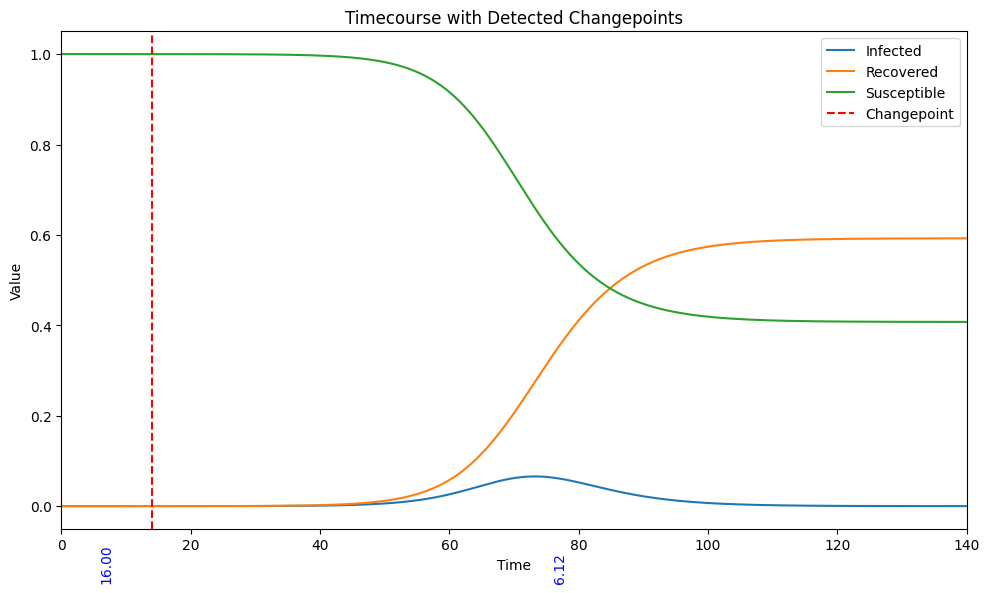

In [21]:
detector, tc = makeDetector(model_num=1045, end_time=140)
detector.detect(max_changepoint=10, min_segment_length=100, min_fractional_reduction=0.001)
fig, _ = detector.plotTimecourseWithChangepoints()